# Part 1
## (ii) Isotherm annealing: Analytical solution 

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively. 

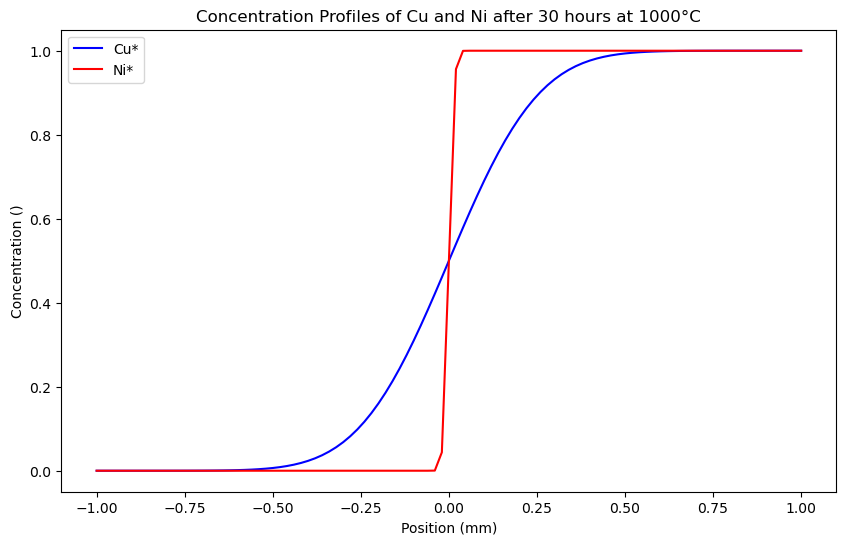

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 101) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=190e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()


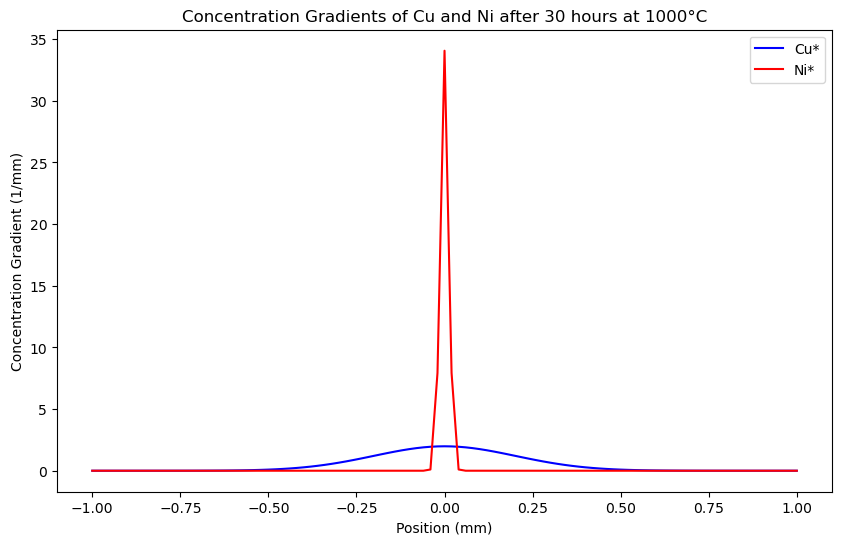

In [3]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()        

In [4]:
# sanity checks
print(Concentration_gradient(0, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
print(D_Cu)
print(D_Ni) #NB, diffusion of Ni is very slow, out of the expected range for fcc metals, but this is what the experimental data says.
# Explaination is that 1000°C is further away from the melting point of Ni than Cu, so diffusion is slower.

1.9819491252865742
1.875777731342469e-13
6.351002637027351e-16


## iii) Numerical solution by finite difference method with explisit timesteps

Numerical solution to substitutional self-diffusion of tracer atoms in bar. I.e. Cu* in Cu and Ni* in Ni (diffusion couple) 

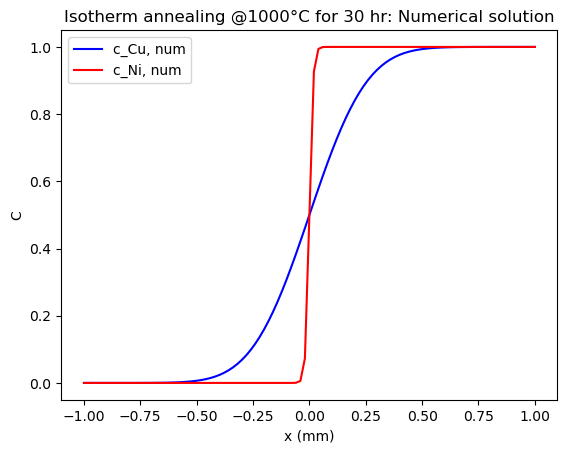

In [9]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
dt=600 # timestep, seconds (should be within bounds of stability, i.e. dt < dx^2/(2*D))

N = int(t_tot/ dt)   # number of time steps
J = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, J+1) # mm
c = np.zeros(J+1)

# Initial condition 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

def num_sol(D, c0, dt, dx, N, J):
    """
    D  : diffusion coefficient (m^2/s)
    c0 : initial concentration array (copy of your initial condition)
    dt, dx : time and space steps
    N  : number of time steps
    J  : number of spatial intervals (len(c0) - 1)
    """
    c = c0.copy()   # don't overwrite the caller's original initial condition
    for n in range(N):
        c_new = c.copy()
        for j in range(1, J):
            c_new[j] = D*dt/dx**2 * (c[j+1] - 2*c[j] + c[j-1]) + c[j]
        c_new[0] = c0[0]   # Dirichlet: hold at initial boundary values
        c_new[J] = c0[J]
        c = c_new
    return c

c_Cu = num_sol(D_Cu, c, dt, dx, N, J)
c_Ni = num_sol(D_Ni, c, dt, dx, N, J)

plt.plot(x, c_Cu, label='c_Cu, num', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()



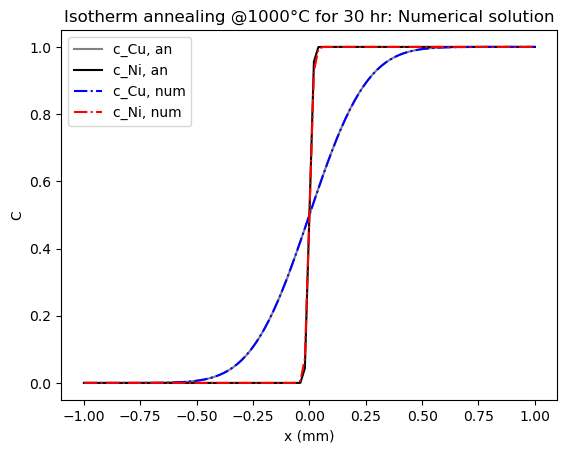

In [11]:
# Plot with analytical solution for comparison 
plt.plot(x, C_Cu, label='c_Cu, an',color='grey')
plt.plot(x, C_Ni, label='c_Ni, an', color='black')
plt.plot(x, c_Cu, label='c_Cu, num',linestyle='dashdot', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num',linestyle='dashdot', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()